In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('Response_Curve.csv')
df = data.copy()

In [3]:
df.head()

,concentration,inhibition_percent
0,0.01,2.1
1,0.02,1.8
2,0.03,2.5
3,0.04,2.2
4,0.05,2.9


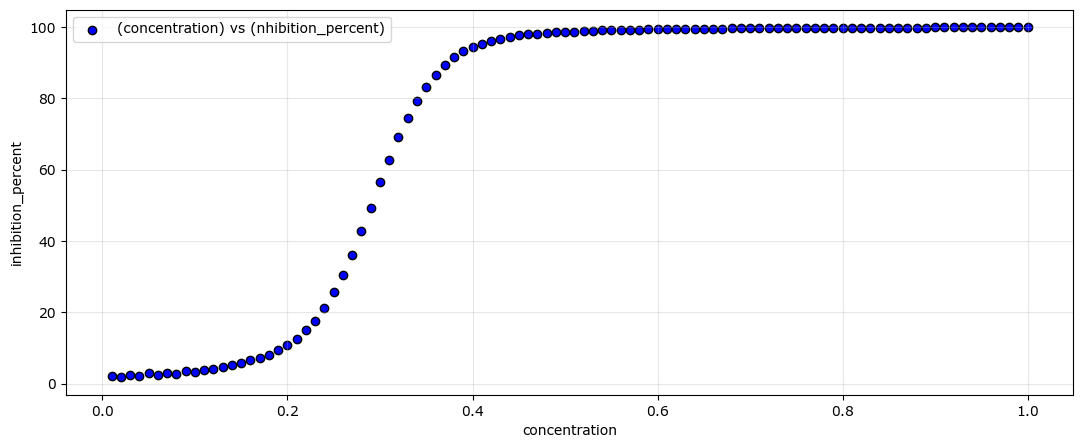

In [4]:
import matplotlib.pyplot as plt

plt.figure( figsize = (13, 5) )

plt.scatter(df['concentration'], df['inhibition_percent'], edgecolor = 'k', color = 'b', label = '(concentration) vs (nhibition_percent)')

plt.xlabel('concentration')
plt.ylabel('inhibition_percent')

plt.grid(True, alpha = 0.3)

plt.legend()

In [5]:
x = df[['concentration']]
y = df[['inhibition_percent']]

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 7, test_size = 0.2)

In [ ]:
def sigmoid(x, a, B1, B2):
    y = a / (1 + np.exp( -B1 * ( x - B2 ) ) )
    return y

In [ ]:
plt.figure( figsize = (13, 5) )

x_plot = np.arange(0.01, 1, 0.03)

plt.plot(x_plot, sigmoid(x_plot, 100, 30, 0.3), 'k--')

In [ ]:
from scipy.optimize import curve_fit

popt, pcov = curve_fit(sigmoid, x_train['concentration'], y_train['inhibition_percent'], p0 = [100, 30, 0.3], bounds = ([30, 10, 0], [100, 100, 1]))
print(f"a: {popt[0]}\nB1: {popt[1]}\nB2: {popt[2]}")

In [ ]:
plt.figure( figsize = (13, 5) )

plt.plot(x_plot, sigmoid(x_plot, *popt), 'b--')

plt.scatter(df['concentration'], df['inhibition_percent'], edgecolor = 'k', color = 'r', label = '(concentration) vs (nhibition_percent)', alpha = 0.5)

plt.xlabel('concentration')
plt.ylabel('inhibition_percent')

plt.grid(True, alpha = 0.3)

plt.legend()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print()
print(f"R2_SCORE: {r2_score(y_test, sigmoid(x_test, *popt)):1.3f}")
print(f"MAE: {mean_absolute_error(y_test, sigmoid(x_test, *popt)):1.2f}")
print(f"MSE: {mean_squared_error(y_test, sigmoid(x_test, *popt)):1.2f}")
print()